# Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights.

**Dataset**: [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/) — 2,443,651 listings, downloaded locally to `data/amz_uk_price_prediction_dataset.csv` (not committed, ~480MB, over GitHub's file size limit).

**Note on the dataset**: the actual columns are `uid, asin, title, stars, reviews, price, isBestSeller, boughtInLastMonth, category` — there is no `brand` column in this version, so the analysis below covers category, price, and rating only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("data/amz_uk_price_prediction_dataset.csv")
print(df.shape)
df.head()

(2443651, 9)


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


---
## Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

### 1. Frequency table

In [3]:
category_freq = df['category'].value_counts()
print(f"{df['category'].nunique()} categories total")
category_freq.head(5)

296 categories total


category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

**Top 5**: `Sports & Outdoors` (836,265), `Beauty` (19,312), `Handmade Clothing, Shoes & Accessories` (19,229), `Bath & Body` (19,092), `Birthday Gifts` (18,978).

### 2. Visualizations

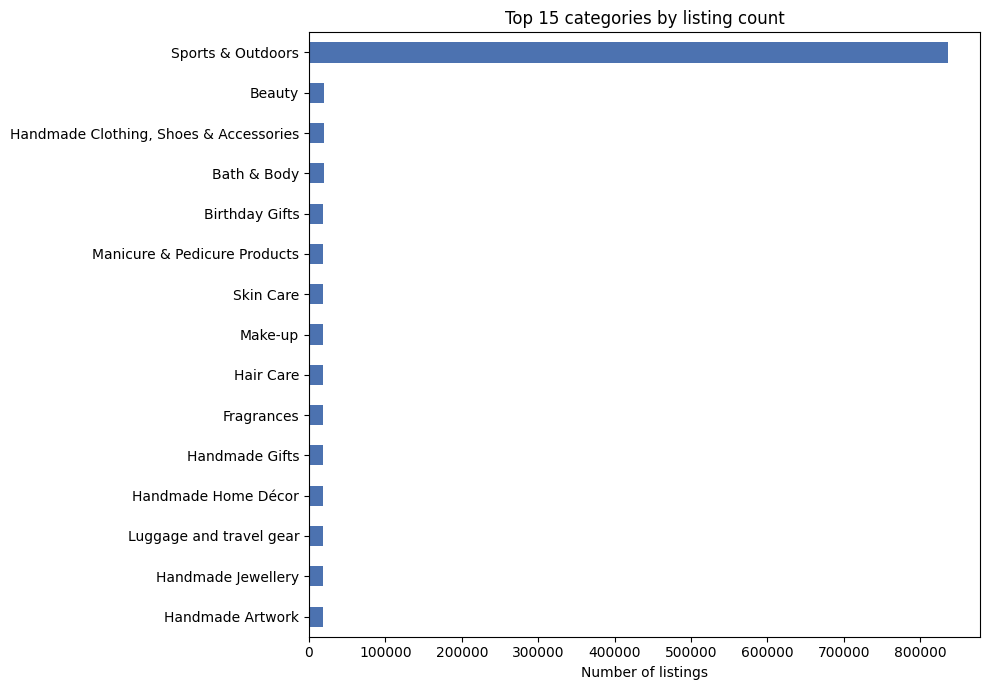

In [4]:
# Full 296-category bar chart is unreadable, so plotting the top 15 by count
top15 = category_freq.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15.iloc[::-1].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Number of listings')
ax.set_ylabel('')
ax.set_title('Top 15 categories by listing count')
plt.tight_layout()
plt.show()

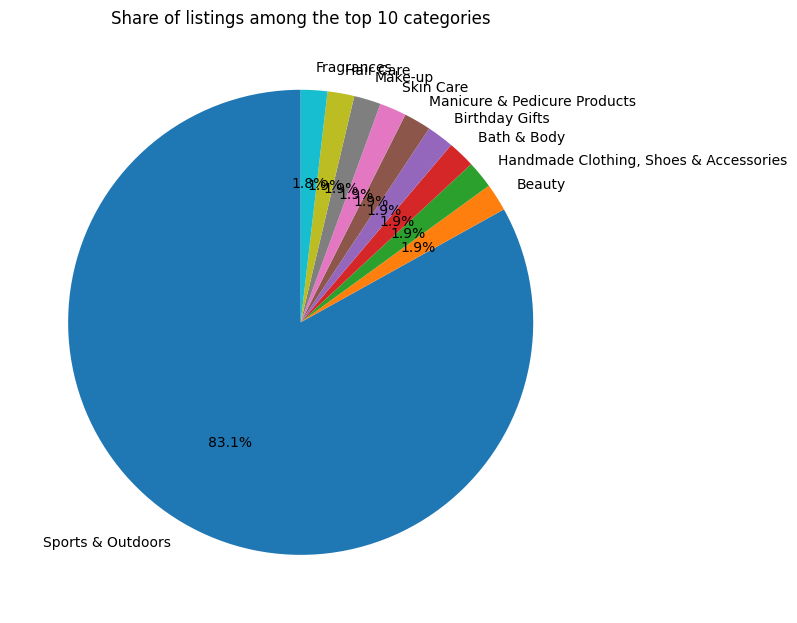

In [5]:
top10 = category_freq.head(10)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(top10, labels=top10.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Share of listings among the top 10 categories')
plt.tight_layout()
plt.show()

**Yes, overwhelmingly** — `Sports & Outdoors` alone is 34.2% of the *entire* 2.44M-row dataset (not just the top 10), more than the other 295 categories combined would need roughly 44 categories its size to match. Even within the "top 10" pie chart it dwarfs every other slice. This single category is an outlier in volume and should be kept in mind (or analyzed separately) in any category-level comparison — it can single-handedly dominate an unweighted average across categories.

---
## Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

### 1. Measures of centrality

In [6]:
price_mean = df['price'].mean()
price_median = df['price'].median()
price_mode = df['price'].mode()[0]

price_mean, price_median, price_mode

(np.float64(89.24380943923661), np.float64(19.09), np.float64(9.99))

The mean (£89.24) sits far above both the median (£19.09) and the mode (£9.99) — a big red flag for right skew before even plotting anything. Most products cluster cheap, but a handful of expensive (or bad-data) listings are dragging the mean way up.

### 2. Measures of dispersion

In [7]:
price_var = df['price'].var()
price_std = df['price'].std()
price_range = df['price'].max() - df['price'].min()
q1, q3 = df['price'].quantile([0.25, 0.75])
price_iqr = q3 - q1

print(f"variance: {price_var:,.2f}")
print(f"std dev: {price_std:,.2f}")
print(f"range: {price_range:,.2f}  (min={df['price'].min()}, max={df['price'].max()})")
print(f"IQR: {price_iqr:.2f}  (Q1={q1}, Q3={q3})")

variance: 119,445.49
std dev: 345.61
range: 100,000.00  (min=0.0, max=100000.0)
IQR: 36.00  (Q1=9.99, Q3=45.99)


In [8]:
# The max (£100,000) is suspicious -- worth checking what it actually is
df[df['price'] == df['price'].max()][['title', 'category', 'price']]

,title,category,price
2008013,HB FBA Test Treadmill,Sports & Outdoors,100000.0


**Extremely varied — and one of those extremes is bad data, not a real product.** The £100,000 maximum turns out to be a single row titled *"HB FBA Test Treadmill"* — a literal test listing, not a real product on sale. The huge gap between the IQR (£36, a tight, believable range for typical products) and the full range (£100,000) shows the spread is being driven by a small number of extreme values, not a genuinely wide-but-real price distribution. This is exactly why IQR is the more trustworthy dispersion measure here.

### 3. Visualizations

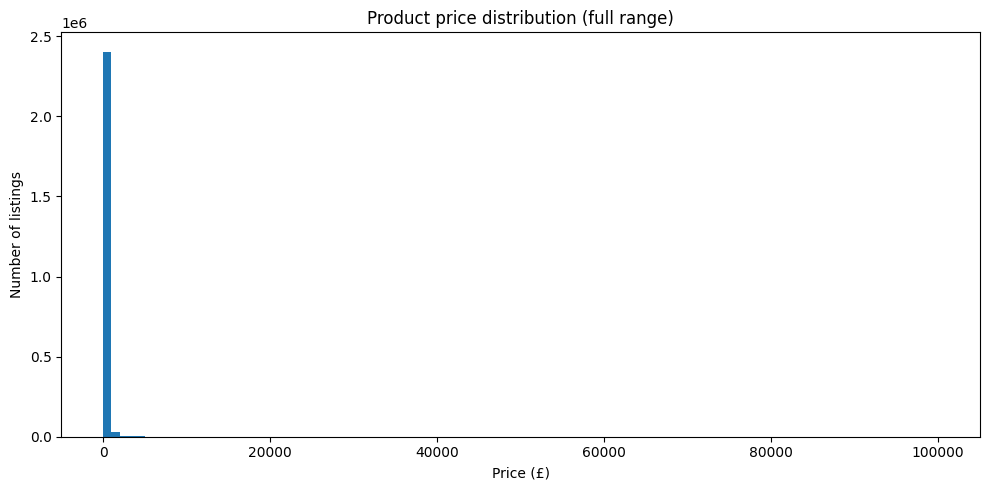

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price'], bins=100)
ax.set_xlabel('Price (£)')
ax.set_ylabel('Number of listings')
ax.set_title('Product price distribution (full range)')
plt.tight_layout()
plt.show()

This first histogram is basically unreadable — one lone bar near £0 and a flat empty line stretching to £100,000, because the x-axis has to stretch to fit that one test-listing outlier. **Fix**: zoom in on the range that actually holds the data, e.g. capping at the 99th percentile or a fixed £0-£200 window.

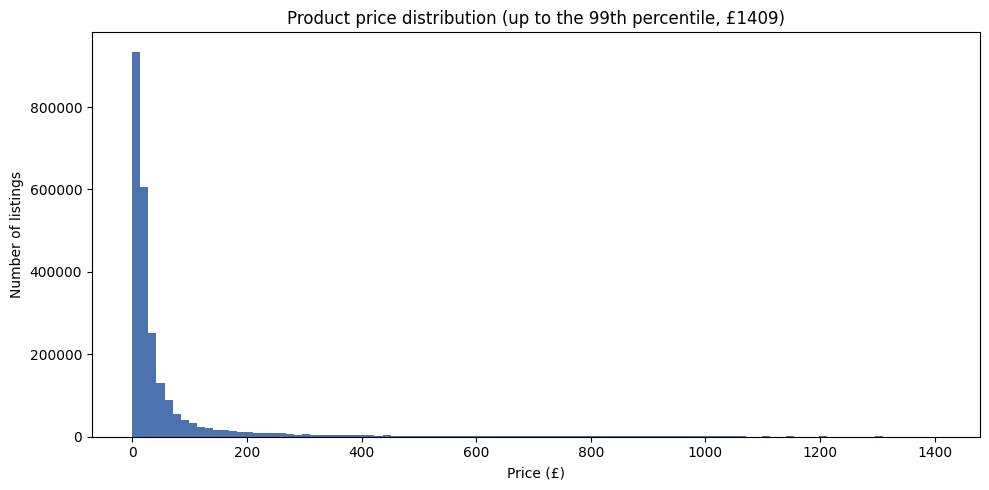

In [10]:
price_99th = df['price'].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['price'] <= price_99th]['price'], bins=100, color='#4C72B0')
ax.set_xlabel('Price (£)')
ax.set_ylabel('Number of listings')
ax.set_title(f'Product price distribution (up to the 99th percentile, £{price_99th:.0f})')
plt.tight_layout()
plt.show()

**Yes** — once zoomed in, most products fall well under £50, with a sharp peak near the £9.99-£19.99 range (matching the mode and median found above) and a long, thin right tail.

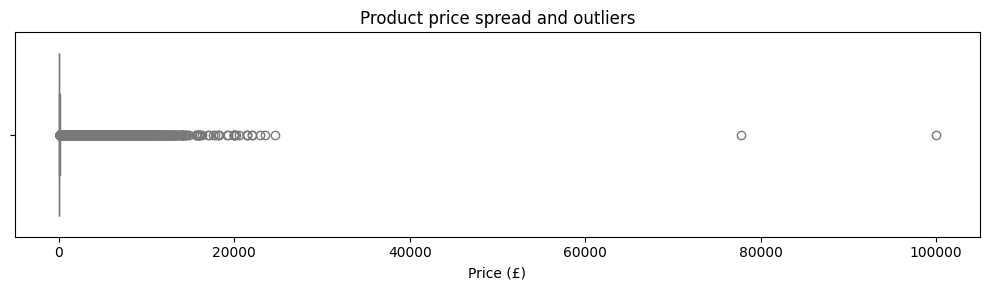

In [11]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df['price'], ax=ax, color='lightblue')
ax.set_xlabel('Price (£)')
ax.set_title('Product price spread and outliers')
plt.tight_layout()
plt.show()

**Yes, many** — the box plot shows an extremely tight box (matching the £36 IQR) against a wide swarm of outlier points stretching far to the right, confirming a large number of products priced well above the typical range, on top of the one confirmed bad-data outlier at £100,000.

---
## Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

Before computing anything: `stars == 0` accounts for **50.2%** of all listings (1,225,641 of 2,443,651). That's almost certainly "no ratings yet" encoded as 0 rather than a genuine 0-star average — the same placeholder pattern flagged in the bivariate lab. Reporting raw statistics on `stars` as-is would silently treat "not yet rated" as "customers hate it," so every measure below is computed **both ways**: on the raw column, and on ratings excluding the zero-placeholder rows.

### 1. Measures of centrality

In [12]:
rated = df[df['stars'] > 0]['stars']

print("Raw (including the 50.2% zero-placeholder rows):")
print(f"  mean={df['stars'].mean():.3f}, median={df['stars'].median():.3f}, mode={df['stars'].mode()[0]:.3f}")
print()
print(f"Rated products only (n={len(rated):,}):")
print(f"  mean={rated.mean():.3f}, median={rated.median():.3f}, mode={rated.mode()[0]:.3f}")

Raw (including the 50.2% zero-placeholder rows):
  mean=2.153, median=0.000, mode=0.000

Rated products only (n=1,218,010):
  mean=4.319, median=4.400, mode=4.500


The raw numbers (mean 2.15, median and mode both 0.0) look like customers mostly hate Amazon UK products — they don't. Once the un-rated half of the dataset is excluded, **the real picture is the opposite**: mean 4.32, median 4.4, mode 4.5. Customers who do rate products rate them very positively, clustered tightly near the top of the scale.

### 2. Measures of dispersion

In [13]:
print("Raw:")
print(f"  var={df['stars'].var():.3f}, std={df['stars'].std():.3f}, IQR={df['stars'].quantile(0.75) - df['stars'].quantile(0.25):.3f}")
print()
print("Rated products only:")
print(f"  var={rated.var():.3f}, std={rated.std():.3f}, IQR={rated.quantile(0.75) - rated.quantile(0.25):.3f}")

Raw:
  var=4.817, std=2.195, IQR=4.400

Rated products only:
  var=0.308, std=0.555, IQR=0.500


The raw spread (std 2.19) looks huge only because it's really measuring the gap between two very different populations — rated and un-rated products — mashed into one column, not genuine variation in customer opinion. Restricted to actually-rated products, the spread shrinks to std 0.56 and an IQR of just 0.5 stars: once someone bothers to rate a product on Amazon UK, opinions are fairly consistent and skew positive.

### 3. Shape of the distribution

In [14]:
print("Raw:")
print(f"  skew={df['stars'].skew():.3f}, kurtosis={df['stars'].kurtosis():.3f}")
print()
print("Rated products only:")
print(f"  skew={rated.skew():.3f}, kurtosis={rated.kurtosis():.3f}")

Raw:


  skew=0.081, kurtosis=-1.926

Rated products only:
  skew=-2.380, kurtosis=9.782


This is the clearest sign that the raw column is really two distributions stitched together: skew on the raw data is nearly zero (0.08, looks almost symmetric) purely because the giant spike at 0 happens to roughly balance the cluster near 4-5. That symmetry is an illusion. Once the placeholder zeros are removed, the *actual* rating distribution is strongly **left-skewed** (skew -2.38) with heavy tails (kurtosis 9.78) — consistent with "most rated products cluster near 4-5 stars, with a thin tail of poorly-rated ones dragging the mean down slightly from the mode."

### 4. Visualizations

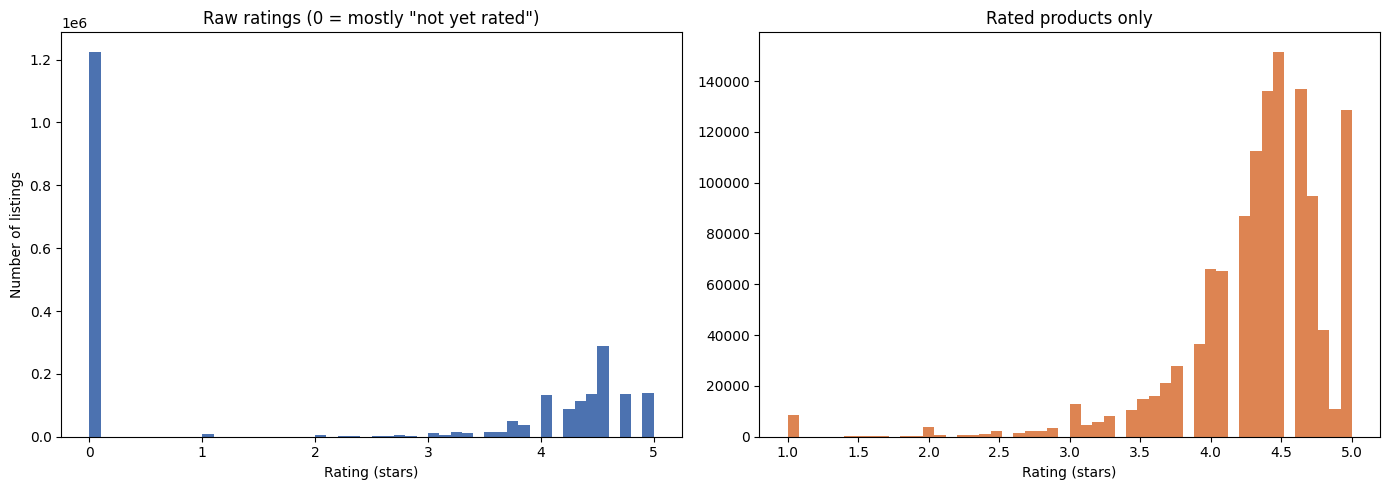

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['stars'], bins=50, color='#4C72B0')
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Number of listings')
axes[0].set_title('Raw ratings (0 = mostly "not yet rated")')

axes[1].hist(rated, bins=50, color='#DD8452')
axes[1].set_xlabel('Rating (stars)')
axes[1].set_title('Rated products only')

plt.tight_layout()
plt.show()

The left panel makes the two-population problem visible at a glance: a massive bar at 0, then a second, completely separate hump around 4-5. The right panel — ratings only — shows the real business-relevant pattern: **4.5 stars is the single most common rating**, and the vast majority of rated products sit between 4.0 and 5.0, with very few below 3.0.